<a href="https://colab.research.google.com/github/RaymCharles/Projet-CNN/blob/main/Projet_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet Machine Learning

## 1. Compréhension et préparation des données

### Task 1 - Chargement du dataset CIFAR-10

In [2]:
import tensorflow as tf

print("TensorFlow :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Bibliothèques de base
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow et Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Vérification de la version TensorFlow
print("Version TensorFlow :", tf.__version__)

Version TensorFlow : 2.20.0


In [4]:
# Chargement du dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [5]:
# Affichage des dimensions du dataset

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de y_train :", y_train.shape)

print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (50000, 32, 32, 3)
Dimensions de y_train : (50000, 1)
Dimensions de X_test : (10000, 32, 32, 3)
Dimensions de y_test : (10000, 1)


#### Réponses aux questions

- Nombre d'images d'entraînement : 50 000
- Nombre d'images de test : 10 000

- Chaque image possède une dimension de 32 × 32 pixels.
- Les images possèdent 3 canaux de couleur (RGB : Red, Green, Blue).

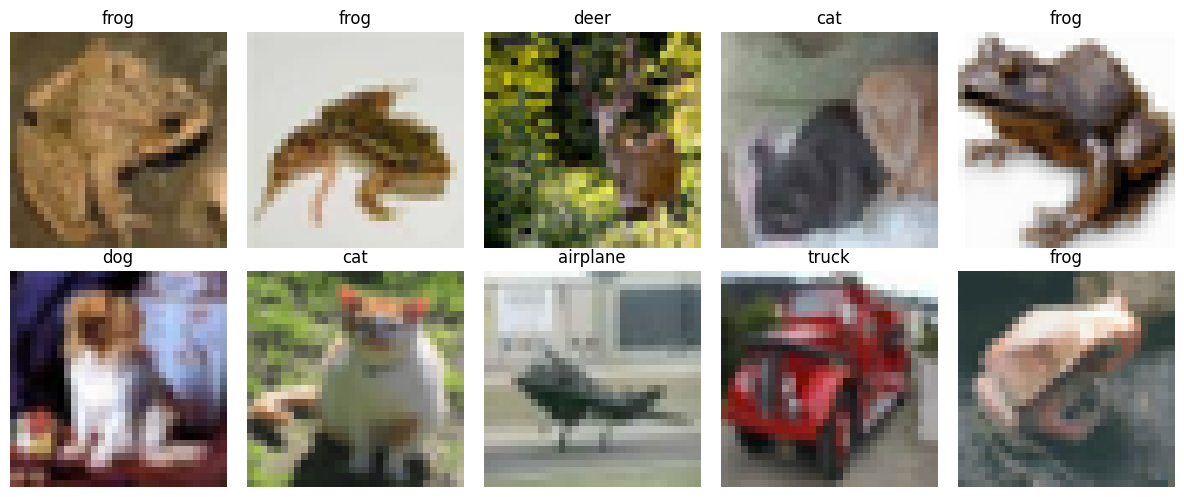

In [6]:
# Noms des classes CIFAR-10

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Affichage de 10 images aléatoires

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    index = np.random.randint(0, len(X_train))

    plt.imshow(X_train[index])

    plt.title(class_names[y_train[index][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Analyse des images

Les images du dataset CIFAR-10 représentent différentes catégories d’objets telles que des avions, des voitures, des oiseaux, des chats ou encore des bateaux.

Les labels sont des données catégorielles. Ils sont initialement représentés par des valeurs numériques comprises entre 0 et 9, chaque valeur correspondant à une classe spécifique.

Les images sont relativement petites (32 × 32 pixels), ce qui rend certaines classes difficiles à distinguer. Pour un humain, certaines images sont facilement reconnaissables, tandis que d’autres peuvent être ambiguës en raison de leur faible résolution.

In [7]:
# Affichage de quelques labels

print("Premiers labels du dataset :")
print(y_train[:10].flatten())

Premiers labels du dataset :
[6 9 9 4 1 1 2 7 8 3]


#### Nature des labels

Les labels sont stockés sous forme de nombres entiers compris entre 0 et 9.

Cependant, ces valeurs numériques ne représentent pas des quantités mais des catégories d’objets (avion, voiture, chat, chien, etc.).

Les labels sont donc des données catégorielles encodées numériquement.

In [8]:
# Vérification des valeurs des pixels avant normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0
Valeur maximale : 255


In [9]:
# Normalisation des images

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
# Vérification après normalisation

print("Valeur minimale :", X_train.min())
print("Valeur maximale :", X_train.max())

Valeur minimale : 0.0
Valeur maximale : 1.0


#### Pourquoi normaliser les données ?

La normalisation consiste à ramener les valeurs des pixels de l’intervalle [0,255] vers l’intervalle [0,1].

Cette étape est importante car elle permet d’éviter que certaines caractéristiques aient des valeurs beaucoup plus grandes que d’autres. Elle facilite également le calcul du gradient lors de l’apprentissage.

#### Impact de la normalisation sur les réseaux de neurones

La normalisation améliore la stabilité numérique du modèle et accélère la convergence pendant l’entraînement.

Elle permet généralement d’obtenir un apprentissage plus rapide, plus stable et de meilleures performances de classification.

In [11]:
# Forme des labels avant one-hot encoding

print("y_train shape avant encodage :", y_train.shape)
print("Exemple de label avant encodage :", y_train[0])

y_train shape avant encodage : (50000, 1)
Exemple de label avant encodage : [6]


In [12]:
# One-hot encoding des labels

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [13]:
# Vérification après one-hot encoding

print("y_train_cat shape après encodage :", y_train_cat.shape)
print("Exemple de label après encodage :", y_train_cat[0])

y_train_cat shape après encodage : (50000, 10)
Exemple de label après encodage : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


#### One-Hot Encoding des labels

Le one-hot encoding transforme chaque label numérique en un vecteur binaire de taille égale au nombre de classes.

Dans CIFAR-10, il y a 10 classes. Un label comme `3` est donc transformé en un vecteur contenant dix valeurs, avec un `1` à la position correspondant à la classe et des `0` ailleurs.

Cette transformation est nécessaire pour un problème de classification multi-classes lorsque l’on utilise une couche de sortie avec 10 neurones et une fonction d’activation softmax.

Elle permet au réseau de comparer ses prédictions, qui sont des probabilités pour chaque classe, avec la vraie classe représentée sous forme de vecteur.

In [14]:
# Comptage du nombre d'images par classe

unique, counts = np.unique(y_train, return_counts=True)

for classe, nombre in zip(unique, counts):
    print(f"{class_names[classe]} : {nombre}")

airplane : 5000
automobile : 5000
bird : 5000
cat : 5000
deer : 5000
dog : 5000
frog : 5000
horse : 5000
ship : 5000
truck : 5000


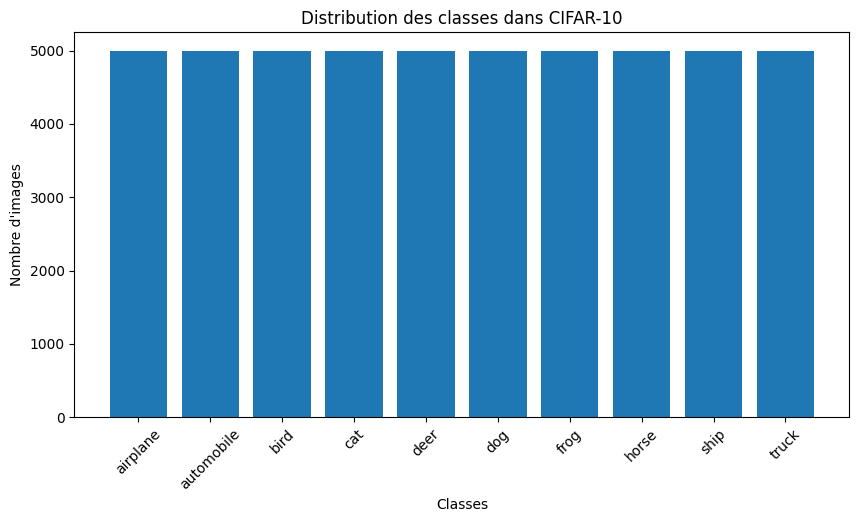

In [15]:
# Distribution des classes

plt.figure(figsize=(10, 5))

plt.bar(class_names, counts)

plt.title("Distribution des classes dans CIFAR-10")
plt.xlabel("Classes")
plt.ylabel("Nombre d'images")

plt.xticks(rotation=45)

plt.show()

#### Analyse de la distribution des classes

Le graphique montre que chaque classe contient environ 5000 images dans l’ensemble d’entraînement.

Le dataset CIFAR-10 est donc équilibré puisque toutes les classes sont représentées par le même nombre d’exemples.

L’analyse de la distribution des classes est importante avant l’entraînement d’un modèle car un déséquilibre pourrait entraîner un biais du modèle vers les classes majoritaires. Dans le cas de CIFAR-10, ce problème n’existe pas puisque les classes sont uniformément réparties.